In [1]:
# ---- Reproducibility
import random
import torch

#seed = 1234
#random.seed(seed)
#torch.manual_seed(seed)
#if torch.cuda.is_available():
#    torch.cuda.manual_seed_all(seed)


In [2]:


# ---- Parameters
n, p = 50, 40
noise_std = 0.1

# (Optional) choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
u = torch.rand(n, dtype=torch.float64, device=device)          # length n
v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

noisy_matrix = rank_1_matrix + noise

# ---- Print (move to CPU for readability if needed)
print("Rank-1 Matrix (Outer Product):")
print(rank_1_matrix.cpu().numpy())

print("\nNoisy Matrix (with Homoscedastic Noise):")
print(noisy_matrix.cpu().numpy())


Rank-1 Matrix (Outer Product):
[[0.04862715 0.03245958 0.0315499  ... 0.0283965  0.02310885 0.04103528]
 [0.48586831 0.32432666 0.31523736 ... 0.28372951 0.23089686 0.41001254]
 [0.79415787 0.53011601 0.51525944 ... 0.46375946 0.37740382 0.67017066]
 ...
 [0.76423805 0.51014395 0.49584709 ... 0.44628737 0.36318517 0.64492205]
 [0.63720158 0.4253446  0.41342426 ... 0.37210267 0.30281424 0.53771904]
 [0.15843653 0.1057595  0.10279558 ... 0.0925212  0.07529303 0.13370076]]

Noisy Matrix (with Homoscedastic Noise):
[[-0.12173185 -0.07355411  0.09514869 ... -0.0097876  -0.17505618
   0.07754991]
 [ 0.48637247  0.50412729  0.43467861 ...  0.2871535   0.18751953
   0.33179582]
 [ 0.71315353  0.4584071   0.22192322 ...  0.47940688  0.08617522
   0.74142361]
 ...
 [ 0.7712525   0.57247031  0.53538034 ...  0.36144649  0.47125995
   0.63609804]
 [ 0.52668618  0.38854404  0.29406761 ...  0.33526163  0.26310768
   0.54403324]
 [ 0.26233787 -0.01180441  0.31428824 ...  0.15758484  0.02728052
   0.02

In [3]:
import sys
import os
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

In [4]:
mycebmf=  cEBMF(data= noisy_matrix) 

mycebmf.initialise_factors()

In [5]:
 
print(mycebmf.L[:,1])
print(mycebmf.F[:,1])

tensor([-0.1329,  0.0242, -0.0823, -0.0829,  0.4101,  0.0217,  0.0309,  0.0744,
        -0.2699,  0.0410, -0.1331,  0.4013, -0.0230, -0.0086,  0.0852,  0.1919,
         0.1233,  0.2335, -0.1546,  0.0769,  0.1593, -0.1149,  0.3171, -0.1618,
        -0.0761, -0.1164, -0.4735, -0.0760,  0.3705,  0.0242,  0.3108, -0.0471,
         0.0506,  0.0839, -0.2183,  0.2169,  0.1656,  0.0413,  0.1137, -0.1919,
         0.0726, -0.1783, -0.3135,  0.0042, -0.2388, -0.3038, -0.1397, -0.0043,
        -0.0212,  0.1417])
tensor([ 0.4258, -0.0963, -0.0099,  0.0642, -0.0802, -0.0129, -0.0852,  0.0407,
        -0.1452,  0.0192,  0.4347, -0.0672, -0.1265,  0.1053, -0.0782, -0.1189,
        -0.2374, -0.2145,  0.2259, -0.0446,  0.0116,  0.0230,  0.0925, -0.3237,
        -0.0603,  0.1597,  0.0444,  0.0293,  0.0673, -0.0226,  0.2515, -0.0359,
         0.0105,  0.0539,  0.1797,  0.1149,  0.0506,  0.0584, -0.1971, -0.2515])


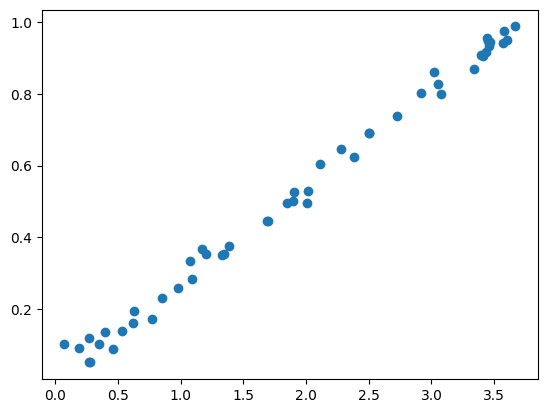

In [6]:
plt.scatter( mycebmf.L[:,0],u)

In [7]:
mycebmf.iter_once()
mycebmf._update_fitted_value()
import numpy as np
K=0
mycebmf.Y_fit 

tensor([[0.0490, 0.0357, 0.0406,  ..., 0.0372, 0.0468, 0.0670],
        [0.4600, 0.3396, 0.3159,  ..., 0.2669, 0.1733, 0.3910],
        [0.7359, 0.5033, 0.3080,  ..., 0.4238, 0.3189, 0.6673],
        ...,
        [0.7723, 0.4814, 0.4874,  ..., 0.4339, 0.3742, 0.6360],
        [0.6123, 0.4246, 0.3951,  ..., 0.3520, 0.2606, 0.5205],
        [0.2247, 0.1159, 0.2452,  ..., 0.1123, 0.0971, 0.1220]])

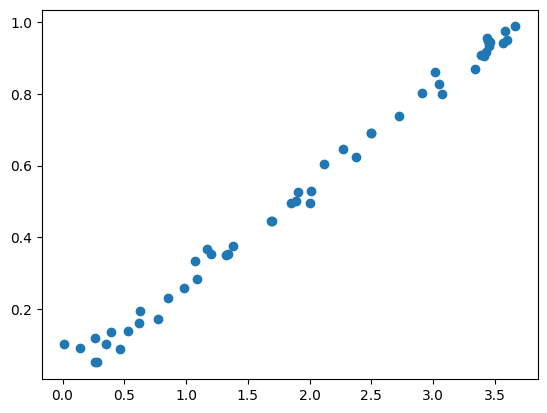

In [8]:
plt.scatter( mycebmf.L[:,0],u)

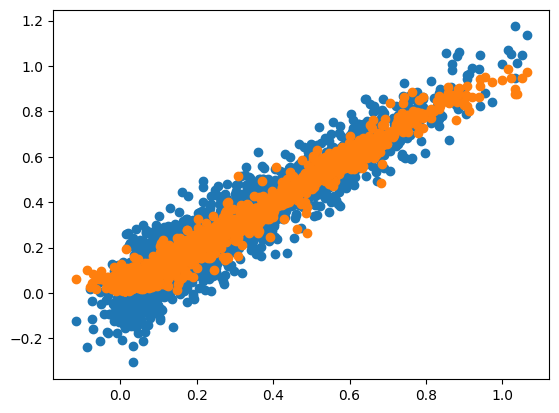

In [9]:
mycebmf.iter_once()  
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)

In [10]:
mycebmf=  cEBMF(data= noisy_matrix) 
mycebmf.initialise_factors()

In [11]:
mycebmf.fit()

Converged after 69 iterations.
Converged after 54 iterations.
Converged after 68 iterations.
Converged after 54 iterations.


CEBMFResult(L=tensor([[ 2.3956e-01, -1.7468e-02,  2.3791e-04],
        [ 1.9408e+00, -1.1416e-02,  4.3105e-04],
        [ 3.0716e+00,  1.0433e-03,  5.5428e-05],
        [ 1.3523e+00, -1.5472e-02, -5.5924e-05],
        [ 3.6419e+00,  5.9267e-02,  4.1418e-04],
        [ 1.4486e-02, -1.0504e-02,  1.5335e-04],
        [ 3.5011e+00,  2.0060e-02,  7.4752e-04],
        [ 1.3665e+00,  6.2945e-03, -5.9475e-04],
        [ 1.2256e+00, -6.5563e-02, -1.6568e-03],
        [ 2.0382e+00,  3.5329e-02, -9.7387e-05],
        [ 1.1159e+00, -1.6733e-01, -1.0392e-04],
        [ 9.4491e-02,  1.4873e-01, -4.8128e-04],
        [ 3.4921e+00, -9.5547e-03, -1.8474e-04],
        [ 1.7288e+00,  4.4600e-03,  3.0951e-04],
        [ 6.3916e-01,  2.6688e-03, -1.5978e-03],
        [ 5.4086e-01,  6.6477e-03, -3.0088e-04],
        [ 2.4477e-01,  7.3286e-03, -7.1565e-04],
        [ 3.5166e+00,  7.7328e-03,  1.1066e-03],
        [ 9.9990e-01, -1.0361e-03, -2.3145e-04],
        [ 3.7317e+00, -1.1800e-03, -6.4398e-06],
      

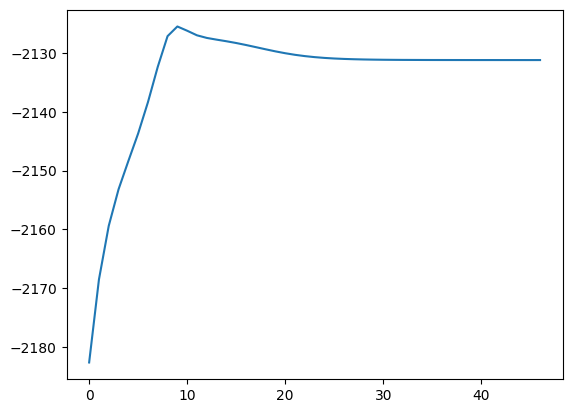

In [12]:
plt.plot(mycebmf.obj)

tensor(0.0036, dtype=torch.float64)

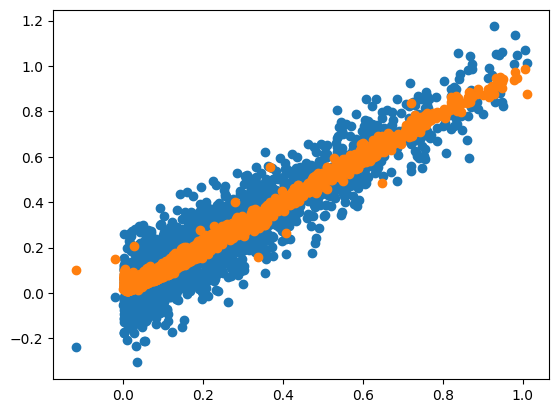

In [13]:
mycebmf._update_fitted_value()
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)
torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)

In [14]:
results =[]
tau_est =[]
for i in range(100):
    # Parameters
    n, p = 50, 40
    noise_std = 0.1

# (Optional) choose device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
    u = torch.rand(n, dtype=torch.float64, device=device)          # length n
    v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
    rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
    noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

    noisy_matrix = rank_1_matrix + noise

 
# Add homoscedastic Gaussian noise (constant variance across the matrix)
    mycebmf=  cEBMF(data= noisy_matrix, K=1) 
    mycebmf.initialise_factors()
    mycebmf.fit(50)
    
    mycebmf._update_fitted_value()
    
    rr = torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)
    results.append( rr)
    tau_est.append(1/mycebmf.tau)
 

Converged after 86 iterations.


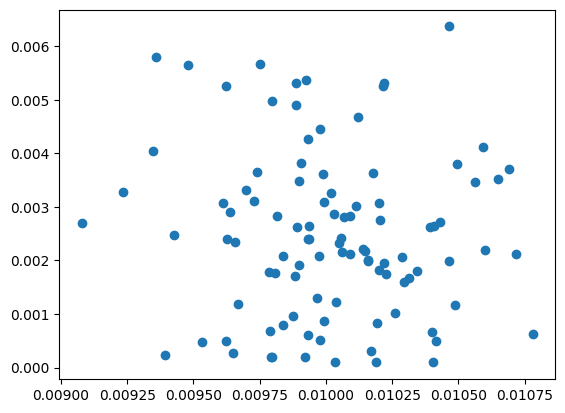

In [15]:
plt.scatter( tau_est, results)

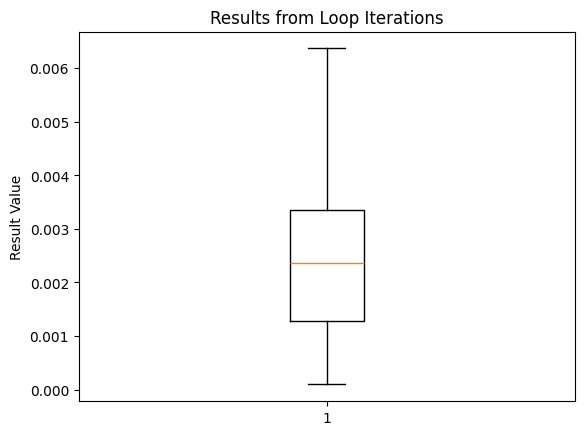

In [16]:
plt.boxplot(results)
plt.title("Results from Loop Iterations")
plt.ylabel("Result Value")
plt.show()

In [17]:
np.quantile(results,q=0.75)

np.float64(0.0033493779636599155)

In [18]:
res= np.asarray(results)
np.mean(res )

np.float64(0.002477433806650658)

In [19]:
np.sqrt(np.var(res ))

np.float64(0.0015314605979209464)

In [20]:
# 0.002615278465597284